#### 423865 中西 滉太
- kaggleのコンペティションを解きました <br>
https://www.kaggle.com/competitions/playground-series-s5e10/overview

- 以下のコードを参考にしました(一部バグが含まれていたので修正しました) <br>
https://www.kaggle.com/code/jockeroika/road-accident-risk#4-Feature-Engineering

In [1]:
import pandas as pd

In [2]:
train = pd.read_csv("dataset/train.csv")
test = pd.read_csv("dataset/test.csv")
sub = pd.read_csv("dataset/sample_submission.csv")

In [3]:
print(train.shape)
missing = train.isnull().sum()
if missing.sum() > 0:
  for col in missing[missing > 0].index:
    print(f"{col}: {missing[col]} missing values")

(517754, 14)


In [4]:
import numpy as np
numerical_cols_train = train.select_dtypes(include=[np.number]).columns.to_list()
if "id" in numerical_cols_train:
  numerical_cols_train.remove("id")
if "accident_risk" in numerical_cols_train and "accident_risk" in train.columns:
  print(f" Mean: {train['accident_risk'].mean():.4f}")
  print(f" Std: {train['accident_risk'].std():.4f}")
  print(f" Min: {train['accident_risk'].min():.4f}")
  print(f" Max: {train['accident_risk'].max():.4f}")

 Mean: 0.3524
 Std: 0.1664
 Min: 0.0000
 Max: 1.0000


In [5]:
categorical_cols_train = train.select_dtypes(include=["object"]).columns.to_list()
if categorical_cols_train:
  for col in categorical_cols_train:
    unique_count = train[col].nunique()
    print(f"{col}: {unique_count} unique values")

road_type: 3 unique values
lighting: 3 unique values
weather: 3 unique values
time_of_day: 3 unique values


In [6]:
numerical_cols_test = test.select_dtypes(include=[np.number]).columns.to_list()
if "id" in numerical_cols_test:
  numerical_cols_test.remove("id")
if "accident_risk" in numerical_cols_test and "accident_risk" in test.columns:
  print(f" Mean: {test['accident_risk'].mean():.4f}")
  print(f" Std: {test['accident_risk'].std():.4f}")
  print(f" Min: {test['accident_risk'].min():.4f}")
  print(f" Max: {test['accident_risk'].max():.4f}")

In [7]:
categorical_cols_test = test.select_dtypes(include=["object"]).columns.to_list()
for col in categorical_cols_test:
  unique_count = test[col].nunique()
  print(f"{col}: {unique_count} unique values")

road_type: 3 unique values
lighting: 3 unique values
weather: 3 unique values
time_of_day: 3 unique values


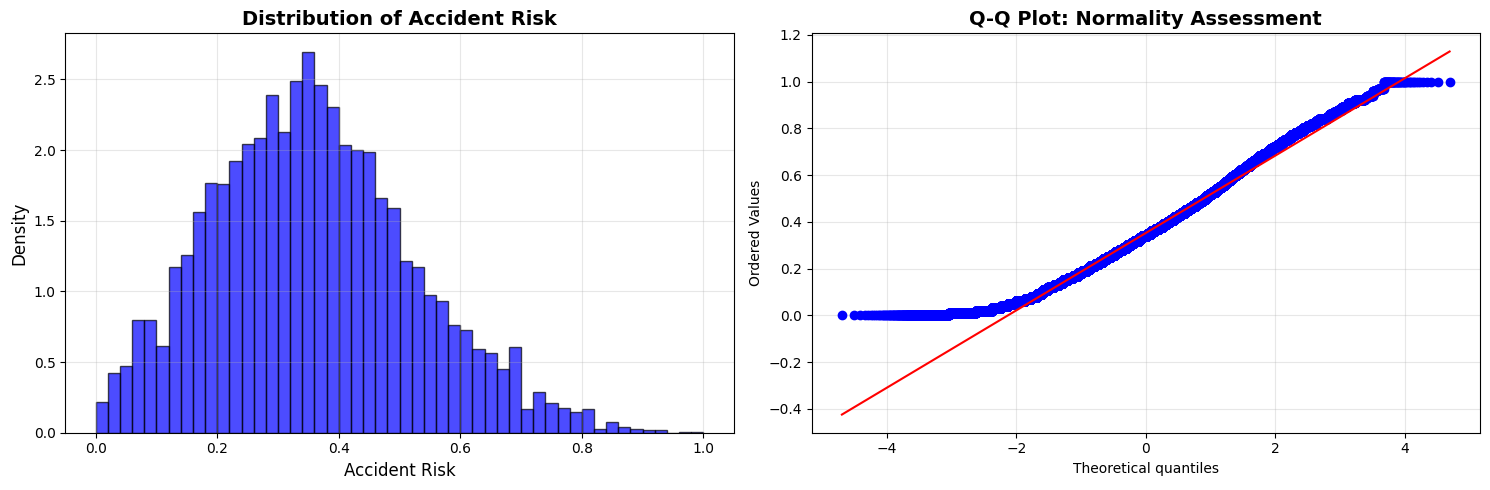

Shapiro-Wilk Test: Statistic=0.9876, p-value=0.0000
The target variable 'accident_risk' is likely not normally distributed (reject H0).


In [8]:
import matplotlib.pyplot as plt
from scipy import stats

target_col = "accident_risk"

if target_col not in train.columns:
  print(f"Target column '{target_col}' not found in training data.")
else:
  fig, axes = plt.subplots(1, 2, figsize=(15, 5))
  
  axes[0].hist(train[target_col], bins=50, density=True, alpha=0.7, color='blue', edgecolor='black')
  axes[0].set_xlabel("Accident Risk", fontsize=12)
  axes[0].set_ylabel("Density", fontsize=12)
  axes[0].set_title("Distribution of Accident Risk", fontsize=14, fontweight='bold')
  axes[0].grid(True, alpha=0.3)
  
  stats.probplot(train[target_col], dist="norm", plot=axes[1])
  axes[1].set_title("Q-Q Plot: Normality Assessment", fontsize=14, fontweight='bold')
  axes[1].grid(True, alpha=0.3)
  
  plt.tight_layout()
  plt.show()
  
  shapiro_stat, shapiro_p = stats.shapiro(train[target_col].sample(min(5000, len(train))))
  print(f"Shapiro-Wilk Test: Statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")
  
  if shapiro_p > 0.05:
    print("The target variable 'accident_risk' is likely normally distributed (fail to reject H0).")
  else:
    print("The target variable 'accident_risk' is likely not normally distributed (reject H0).")

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

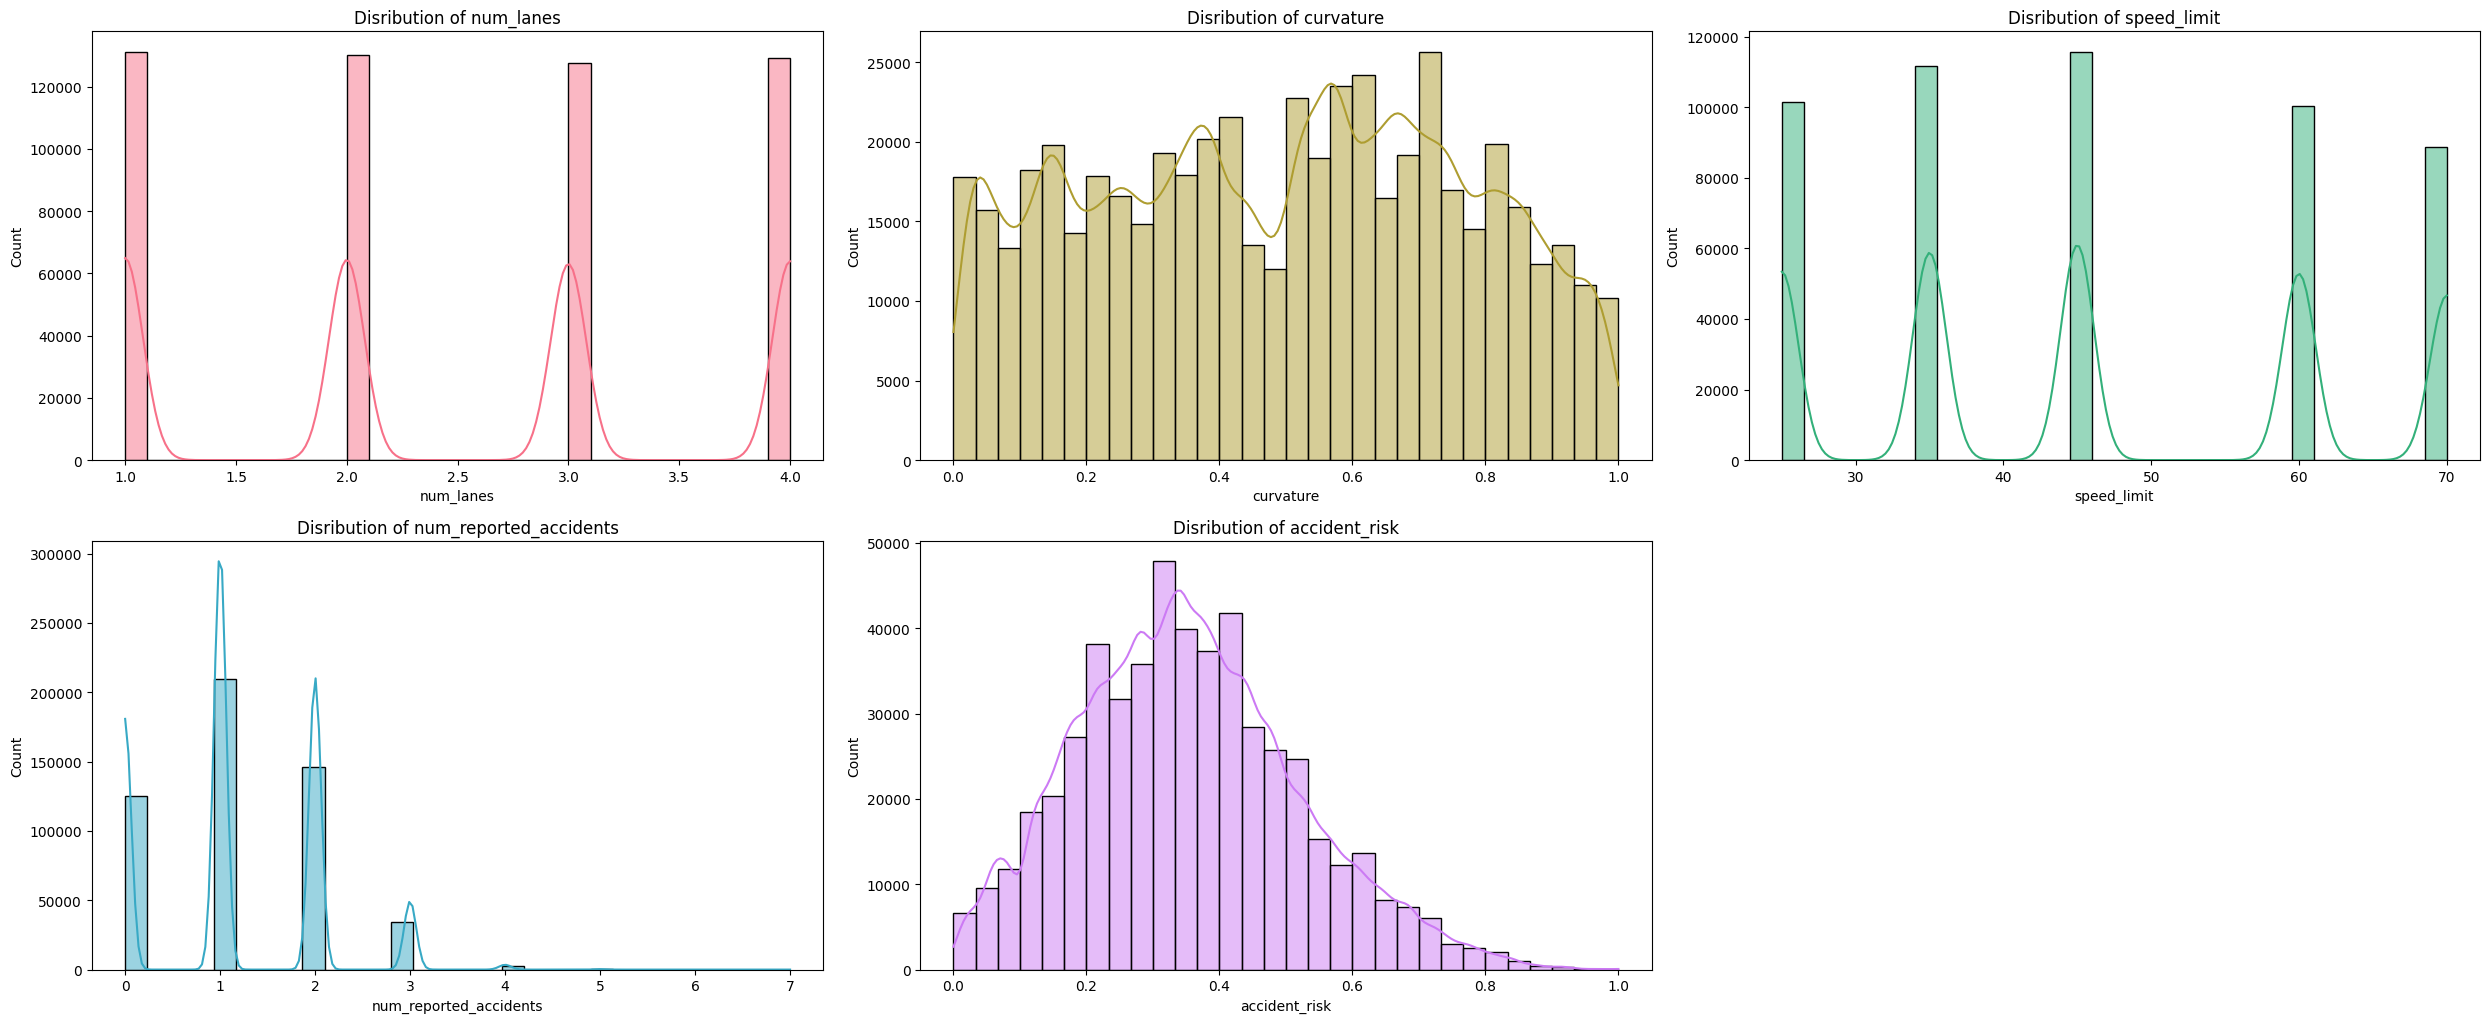

In [9]:
import seaborn as sns
palette = sns.color_palette("husl", len(numerical_cols_train))

plt.figure(figsize=(25, 15))
for i, col in enumerate(numerical_cols_train, 1):
  plt.subplot(3, 3, i)
  sns.histplot(train[col], kde=True, color=palette[i-1], bins=30)
  plt.title(f"Disribution of {col}")
plt.tight_layout()
plt.show()

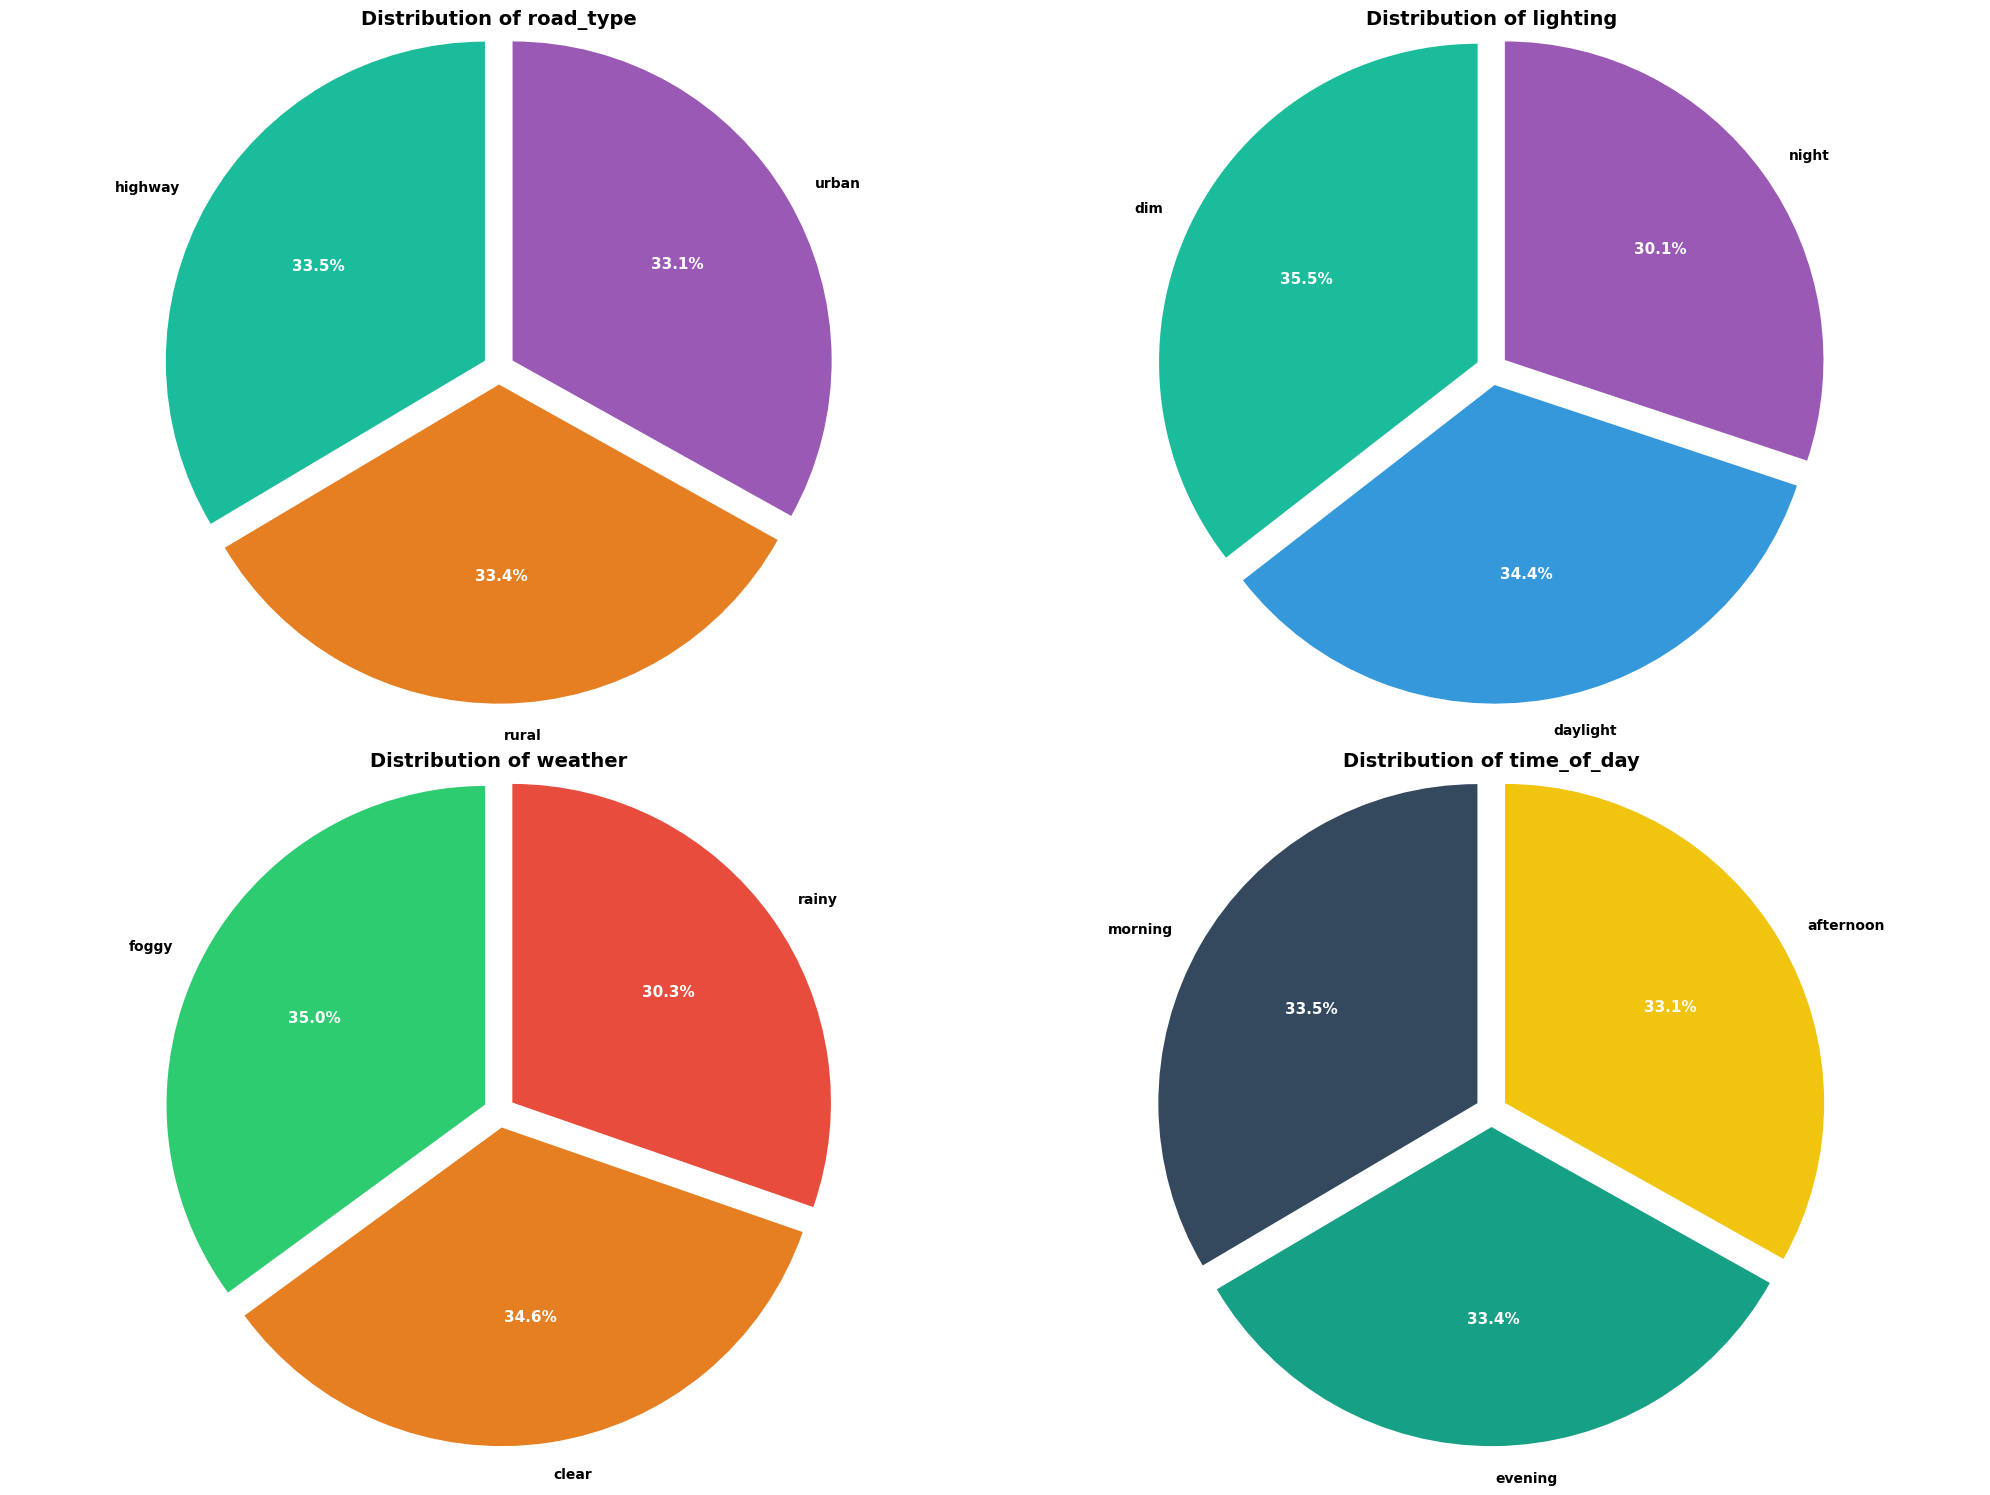

In [10]:
# Color palettes
color_palettes = {
    'lighting': ['#1abc9c', '#3498db', '#9b59b6', '#f39c12'],
    'weather': ['#2ecc71', '#e67e22', '#e74c3c'],
    'time_of_day': ['#34495e', '#16a085', '#f1c40f','#f39c12'],
    'road_type': ['#1abc9c', '#e67e22', '#9b59b6', '#f39c12', '#3498db']
}

plt.figure(figsize=(20, 15))

for i, col in enumerate(categorical_cols_train, 1):
    plt.subplot(2, 2, i)
    value_counts = train[col].value_counts()
    colors = color_palettes[col][:len(value_counts)]
    
    wedges, texts, autotexts = plt.pie(
        value_counts,
        labels=value_counts.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=colors,
        explode=[0.05]*len(value_counts),
        textprops={"fontsize": 10, "fontweight": "bold"}
    )
    
    for autotext in autotexts:
        autotext.set_color("white")
        autotext.set_fontweight("bold")
        autotext.set_fontsize(11)
        
    plt.title(f"Distribution of {col}", fontsize=14, fontweight='bold', y=0.98)
    plt.axis("equal")    
    
plt.tight_layout()

plt.show()

In [11]:
CATEGORICAL_FEATURES = ['road_type', 'lighting', 'weather', 'time_of_day']
BOOLEAN_FEATURES = ['road_signs_present', 'public_road', 'holiday', 'school_season']
NUMERICAL_FEATURES = ['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents']
TARGET = 'accident_risk'
ID_COL = 'id'

In [12]:
from sklearn.preprocessing import LabelEncoder

def enginner_feature(df):
  df_eng = df.copy()
  
  df_eng["curv_speed"] = df_eng["curvature"] * df_eng["speed_limit"]
  df_eng["lanes_speed"] = df_eng["num_lanes"] * df_eng["speed_limit"]
  df_eng["accidents_speed"] = df_eng["num_reported_accidents"] * df_eng["speed_limit"]
  df_eng["accidents_curv"] = df_eng["num_reported_accidents"] * df_eng["curvature"]
  
  df_eng["curvature_sq"] = df_eng["curvature"] ** 2
  df_eng["curvature_cube"] = df_eng["curvature"] ** 3
  df_eng["speed_sq"] = df_eng["speed_limit"] ** 2
  
  df_eng["risk_intensity"] = (df_eng["curvature"] * df_eng["speed_limit"]) / 50
  df_eng["lane_capacity_risk"] = (5 - df_eng["num_lanes"]) * df_eng["speed_limit"]
  df_eng["accidents_per_lane"] = df_eng["num_reported_accidents"] / (df_eng["num_lanes"] + 1)
  
  df_eng["high_risk_combo"] = ((df_eng["curvature"] > 0.5) &
                               (df_eng["speed_limit"] >= 60)).astype(int)
  
  return df_eng

train_processed = train.copy()
test_processed = test.copy()

for col in BOOLEAN_FEATURES:
  train_processed[col] = train_processed[col].astype(int)
  test_processed[col] = test_processed[col].astype(int)
  

label_encoders = {}
for col in CATEGORICAL_FEATURES:
  le = LabelEncoder()
  train_processed[f"{col}_enc"] = le.fit_transform(train_processed[col])
  test_processed[f"{col}_enc"] = le.transform(test_processed[col])
  label_encoders[col] = le
  
train_engineered = enginner_feature(train_processed)
test_engineered = enginner_feature(test_processed)

In [13]:
exclude_cols = [ID_COL, TARGET] + CATEGORICAL_FEATURES
feature_cols = [col for col in train_engineered.columns if col not in exclude_cols]

X_train = train_engineered[feature_cols]
y_train = train_engineered[TARGET]
X_test = test_engineered[feature_cols]

print(f"Training matrix: {X_train.shape}")
print(f"Target vector: {X_test.shape}")

Training matrix: (517754, 23)
Target vector: (172585, 23)


In [14]:
from sklearn.model_selection import KFold
N_SPLITS = 7
kfold = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof_xgb1 = np.zeros(len(X_train))
oof_xgb2 = np.zeros(len(X_train))
test_xgb1 = np.zeros(len(X_test))
test_xgb2 = np.zeros(len(X_test))
scores_xgb1, scores_xgb2 = [], []
models_xgb1, models_xgb2 = [], []

In [15]:
import optuna
import xgboost as xgb
from sklearn.metrics import mean_squared_error


def objective(trial):
  params = {
    'n_estimators': trial.suggest_int('n_estimators', 3000, 10000),
    'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
    'max_depth': trial.suggest_int('max_depth', 6, 12),
    'min_child_weight': trial.suggest_int('min_child_weight', 1, 6),
    'subsample': trial.suggest_float('subsample', 0.6, 1.0),
    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
    'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 2.0),
    'random_state': 42,
    'tree_method': 'gpu_hist',
    'gpu_id': 0,
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse'
  }
  
  oof = np.zeros(len(X_train))
  for train_idx, val_idx in kfold.split(X_train):
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model = xgb.XGBRegressor(**params)
    model.fit(
      X_fold_train, y_fold_train,
      eval_set=[(X_fold_val, y_fold_val)],
      early_stopping_rounds=100,
      verbose=False
    )
    oof[val_idx] = model.predict(X_fold_val)
  
  rmse = np.sqrt(mean_squared_error(y_train, oof))
  return rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=15)

print("Best trial:")
print(study.best_trial.params)
best_params = study.best_trial.params

xgb1_params = best_params.copy()
xgb1_params.update({
  "random_state": 42,
  "tree_method": "gpu_hist",
  "gpu_id": 0,
  "objective": "reg:squarederror",
  "eval_metric": "rmse"
})

xgb2_params = xgb1_params.copy()
xgb2_params["learning_rate"] = xgb2_params["learning_rate"] * 1.2
xgb2_params["subsample"] = min(1.0, xgb2_params["subsample"] + 0.05)

print("Training XGB Model 1")
for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_train), 1):
  X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
  y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
  
  model = xgb.XGBRegressor(**xgb1_params)
  model.fit(
    X_fold_train, y_fold_train,
    eval_set=[(X_fold_val, y_fold_val)],
    early_stopping_rounds=200,
    verbose=False
  )
  
  oof_xgb1[val_idx] = model.predict(X_fold_val)
  test_xgb1 += model.predict(X_test) / N_SPLITS
  
  fold_rmse = np.sqrt(mean_squared_error(y_fold_val, oof_xgb1[val_idx]))
  scores_xgb1.append(fold_rmse)
  models_xgb1.append(model)
  
  print(f"Fold {fold_idx}: {N_SPLITS} RMSE = {fold_rmse:.4f}")

xgb1_oof_rmse = np.sqrt(mean_squared_error(y_train, oof_xgb1))
print(f"XGB Model 1 OOF RMSE: {xgb1_oof_rmse:.4f}")

print("Training XGB Model 2")
for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_train), 1):
  X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
  y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
  
  model = xgb.XGBRegressor(**xgb2_params)
  model.fit(
    X_fold_train, y_fold_train,
    eval_set=[(X_fold_val, y_fold_val)],
    early_stopping_rounds=200,
    verbose=False
  )
  
  oof_xgb2[val_idx] = model.predict(X_fold_val)
  test_xgb2 += model.predict(X_test) / N_SPLITS
  
  fold_rmse = np.sqrt(mean_squared_error(y_fold_val, oof_xgb2[val_idx]))
  scores_xgb2.append(fold_rmse)
  models_xgb2.append(model)
  
  print(f"Fold {fold_idx}: {N_SPLITS} RMSE = {fold_rmse:.4f}")

xgb2_oof_rmse = np.sqrt(mean_squared_error(y_train, oof_xgb2))

[I 2025-10-11 04:24:00,800] A new study created in memory with name: no-name-f054ca1c-924d-4abc-9d0b-1b4da2a094c6
/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [04:24:01] WARNING: /workspace/src/common/error_msg.cc:45: `gpu_id` is deprecated since2.0.0, use `device` instead. E.g. device=cpu/cuda/cuda:0
  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [04:24:01] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-package

Best trial:
{'n_estimators': 6220, 'learning_rate': 0.007066769006632853, 'max_depth': 8, 'min_child_weight': 2, 'subsample': 0.8291074152733131, 'colsample_bytree': 0.7732481117792144, 'reg_alpha': 0.8860879345045556, 'reg_lambda': 1.6778499075845676}
Training XGB Model 1


/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [04:55:08] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [04:55:28] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)


Fold 1: 7 RMSE = 0.0559


/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [04:55:28] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [04:55:51] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)


...

Fold 5: 7 RMSE = 0.0560


/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [04:59:32] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [04:59:52] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)


Fold 6: 7 RMSE = 0.0559


/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [04:59:52] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [05:00:15] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)


Fold 7: 7 RMSE = 0.0558


In [16]:
best_rmse = 1e9
best_w = None
best_test = None

for w1 in np.linspace(0, 1, 101):
  w2 = 1 - w1
  oof_ens = w1 * oof_xgb1 + w2 * oof_xgb2
  rmse = np.sqrt(mean_squared_error(y_train, oof_ens))
  if rmse < best_rmse:
    best_rmse = rmse
    best_w = (w1, w2)
    best_test = w1 * test_xgb1 + w2 * test_xgb2

print(f"Best ensemble RMSE: {best_rmse:.4f} with weights: XGB1={best_w[0]:.2f}, XGB2={best_w[1]:.2f}")

submission = pd.DataFrame({
  "id": test["id"],
  "accident_risk": best_test
})

assert submission.shape == (len(test), 2)
submission.to_csv("submission.csv", index=False)
print("Submission file 'submission.csv' created.")

Best ensemble RMSE: 0.0560 with weights: XGB1=0.05, XGB2=0.95
Submission file 'submission.csv' created.
